In [1]:
"""
Customer Segmentation Analysis - Part 4: Clustering & Insights
==============================================================

This notebook continues the segmentation analysis with:
1. Exploratory Data Analysis (EDA)
2. Feature selection and preparation for clustering
3. K-means clustering with optimal k selection
4. Segment characterization and profiling
5. Business insights and recommendations
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load prepared customer features
customer_features = pd.read_csv('customer_features_prepared.csv')
print(f"Loaded customer features: {customer_features.shape}")


Loaded customer features: (121112, 26)


In [3]:
# ============================================================================
# PART 3: EXPLORATORY DATA ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("PART 4: EXPLORATORY DATA ANALYSIS")
print("=" * 80)


PART 4: EXPLORATORY DATA ANALYSIS


In [4]:
import pandas as pd
pd.set_option("display.max_columns", None)
customer_features.head()

,NO_TOKEN_CB,DT_VENTE_first_purchase,DT_VENTE_last_purchase,DT_VENTE_shopping_days,CD_TICKET_UNIQUE_total_transactions,MT_TTC_NET_total_spend,MT_TTC_NET_avg_transaction_value,LB_METIER_dept_diversity,LB_FAMILLE_family_diversity,TOTAL_QTY_total_items_bought,QT_UVC_total_units,QT_POIDS_total_weight,ID_MAG_TIERS_stores_visited,QTY_PROMO_NAT_nat_promo_qty,QTY_PROMO_STORE_store_promo_qty,recency_days,customer_lifetime_days,transactions_per_month,avg_items_per_basket,avg_basket_value,unit_weight_ratio,promo_percentage,national_vs_store_promo_ratio,store_loyalty_score,product_diversity_score,avg_days_between_visits
0,00000ED6FFB345A27CF94114C9819546E9E65D333D0D10...,2025-12-09,2025-12-10,2,2,26.59,1.564118,3,10,19.003,15.61,3.393,3,3.445,0.0,14,1,1.935484,9.50150,13.2950,3.553380,18.128717,3.445,0.333333,30,0.5
1,00000F282C0A8BE112B1CB5EBCEB61673125F374902663...,2025-12-05,2025-12-23,4,4,71.55,3.110870,4,17,32.997,21.98,11.017,4,0.000,0.0,1,18,2.500000,8.24925,17.8875,1.829075,0.000000,0.000,0.250000,68,4.5
2,00005F300675C1E7BA7847B7759248F908230E87BC1EE3...,2025-12-21,2025-12-21,1,1,37.04,6.173333,3,5,8.460,7.73,0.730,3,0.000,0.0,3,0,1.000000,8.46000,37.0400,4.468208,0.000000,0.000,0.333333,15,0.0
3,0001421783EEDB9B602293092CB337D3A69B84C3B42712...,2025-12-18,2025-12-22,2,2,49.39,4.490000,4,9,12.586,11.56,1.026,4,0.000,0.0,2,4,1.764706,6.29300,24.6950,5.705824,0.000000,0.000,0.250000,36,2.0
4,0001B89407D2DCFD6749D4C8A1B0A164E010BA61B1C68D...,2025-12-22,2025-12-22,1,1,21.98,7.326667,2,2,4.000,4.00,0.000,2,0.000,0.0,2,0,1.000000,4.00000,21.9800,4.000000,0.000000,0.000,0.500000,4,0.0



[STEP 3.1] Analyzing feature distributions...


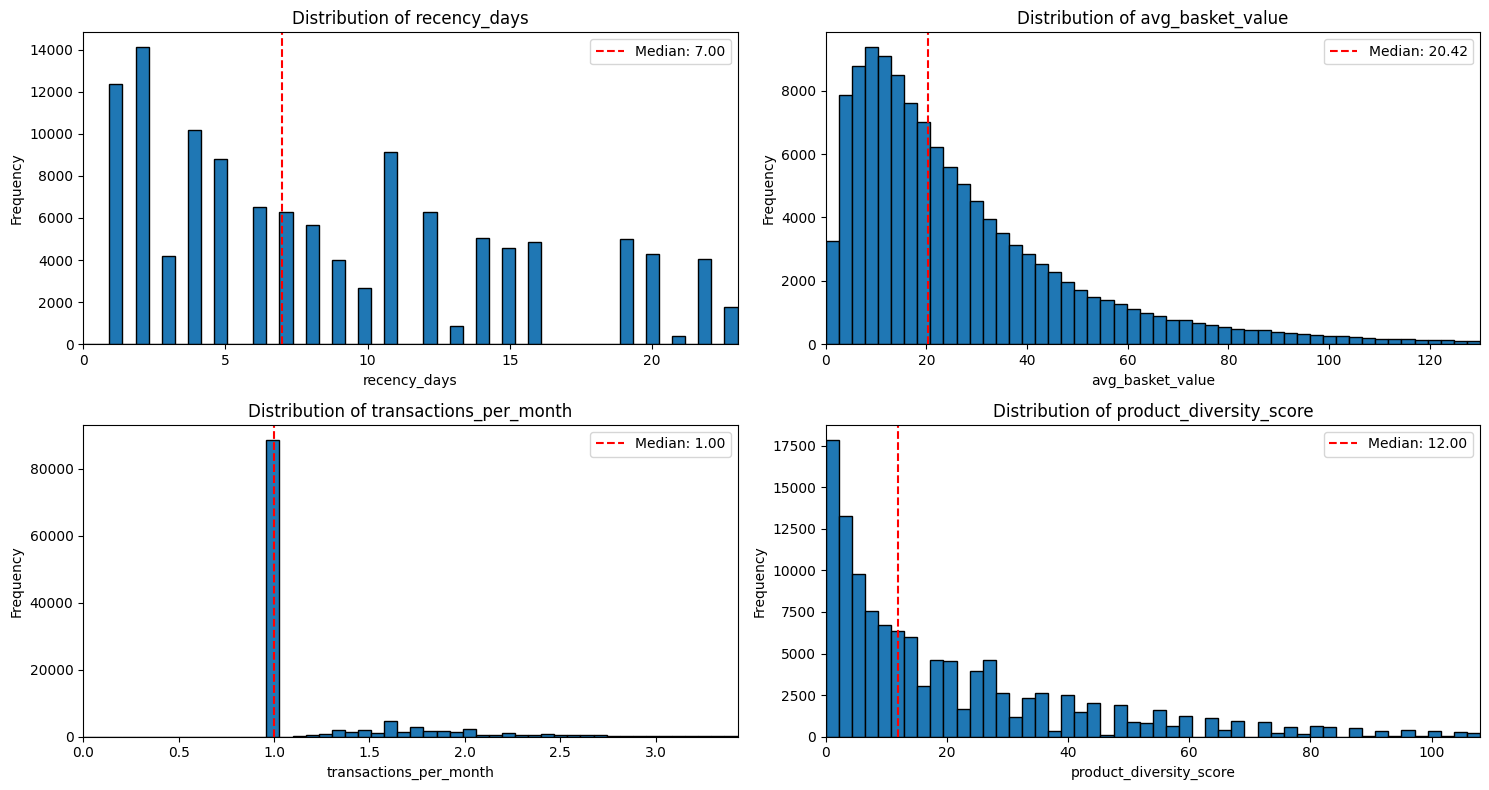

✓ Distribution plots saved as 'feature_distributions.png'


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# STEP 3.1: Distribution Analysis
# ============================================================================

print("\n[STEP 3.1] Analyzing feature distributions...")

key_features = [
    "recency_days",
    "avg_basket_value",
    "transactions_per_month",
    "product_diversity_score",
]

# --- settings
BINS = 50
CAP_AT_QUANTILE = 0.99  # set to None to disable cap (e.g. None)
USE_LOG_X = False       # set True if you prefer log scale (don't use with range cap)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    ax = axes[idx]

    if feature not in customer_features.columns:
        ax.set_title(f"{feature} (missing)")
        ax.axis("off")
        continue

    s = customer_features[feature].dropna()

    # Handle empty column
    if len(s) == 0:
        ax.set_title(f"Distribution of {feature} (no data)")
        ax.axis("off")
        continue

    # Optional cap on x-axis using quantile to avoid long-tail stretching the plot
    if CAP_AT_QUANTILE is not None and not USE_LOG_X:
        xmax = float(s.quantile(CAP_AT_QUANTILE))
        if np.isfinite(xmax) and xmax > 0:
            ax.hist(s, bins=BINS, edgecolor="black", range=(0, xmax))
            ax.set_xlim(0, xmax)
        else:
            ax.hist(s, bins=BINS, edgecolor="black")
    else:
        ax.hist(s, bins=BINS, edgecolor="black")

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

    med = float(s.median())
    ax.axvline(med, color="red", linestyle="--", label=f"Median: {med:.2f}")
    ax.legend()

    if USE_LOG_X:
        ax.set_xscale("log")

plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("✓ Distribution plots saved as 'feature_distributions.png'")


[STEP 3.2] Correlation analysis...


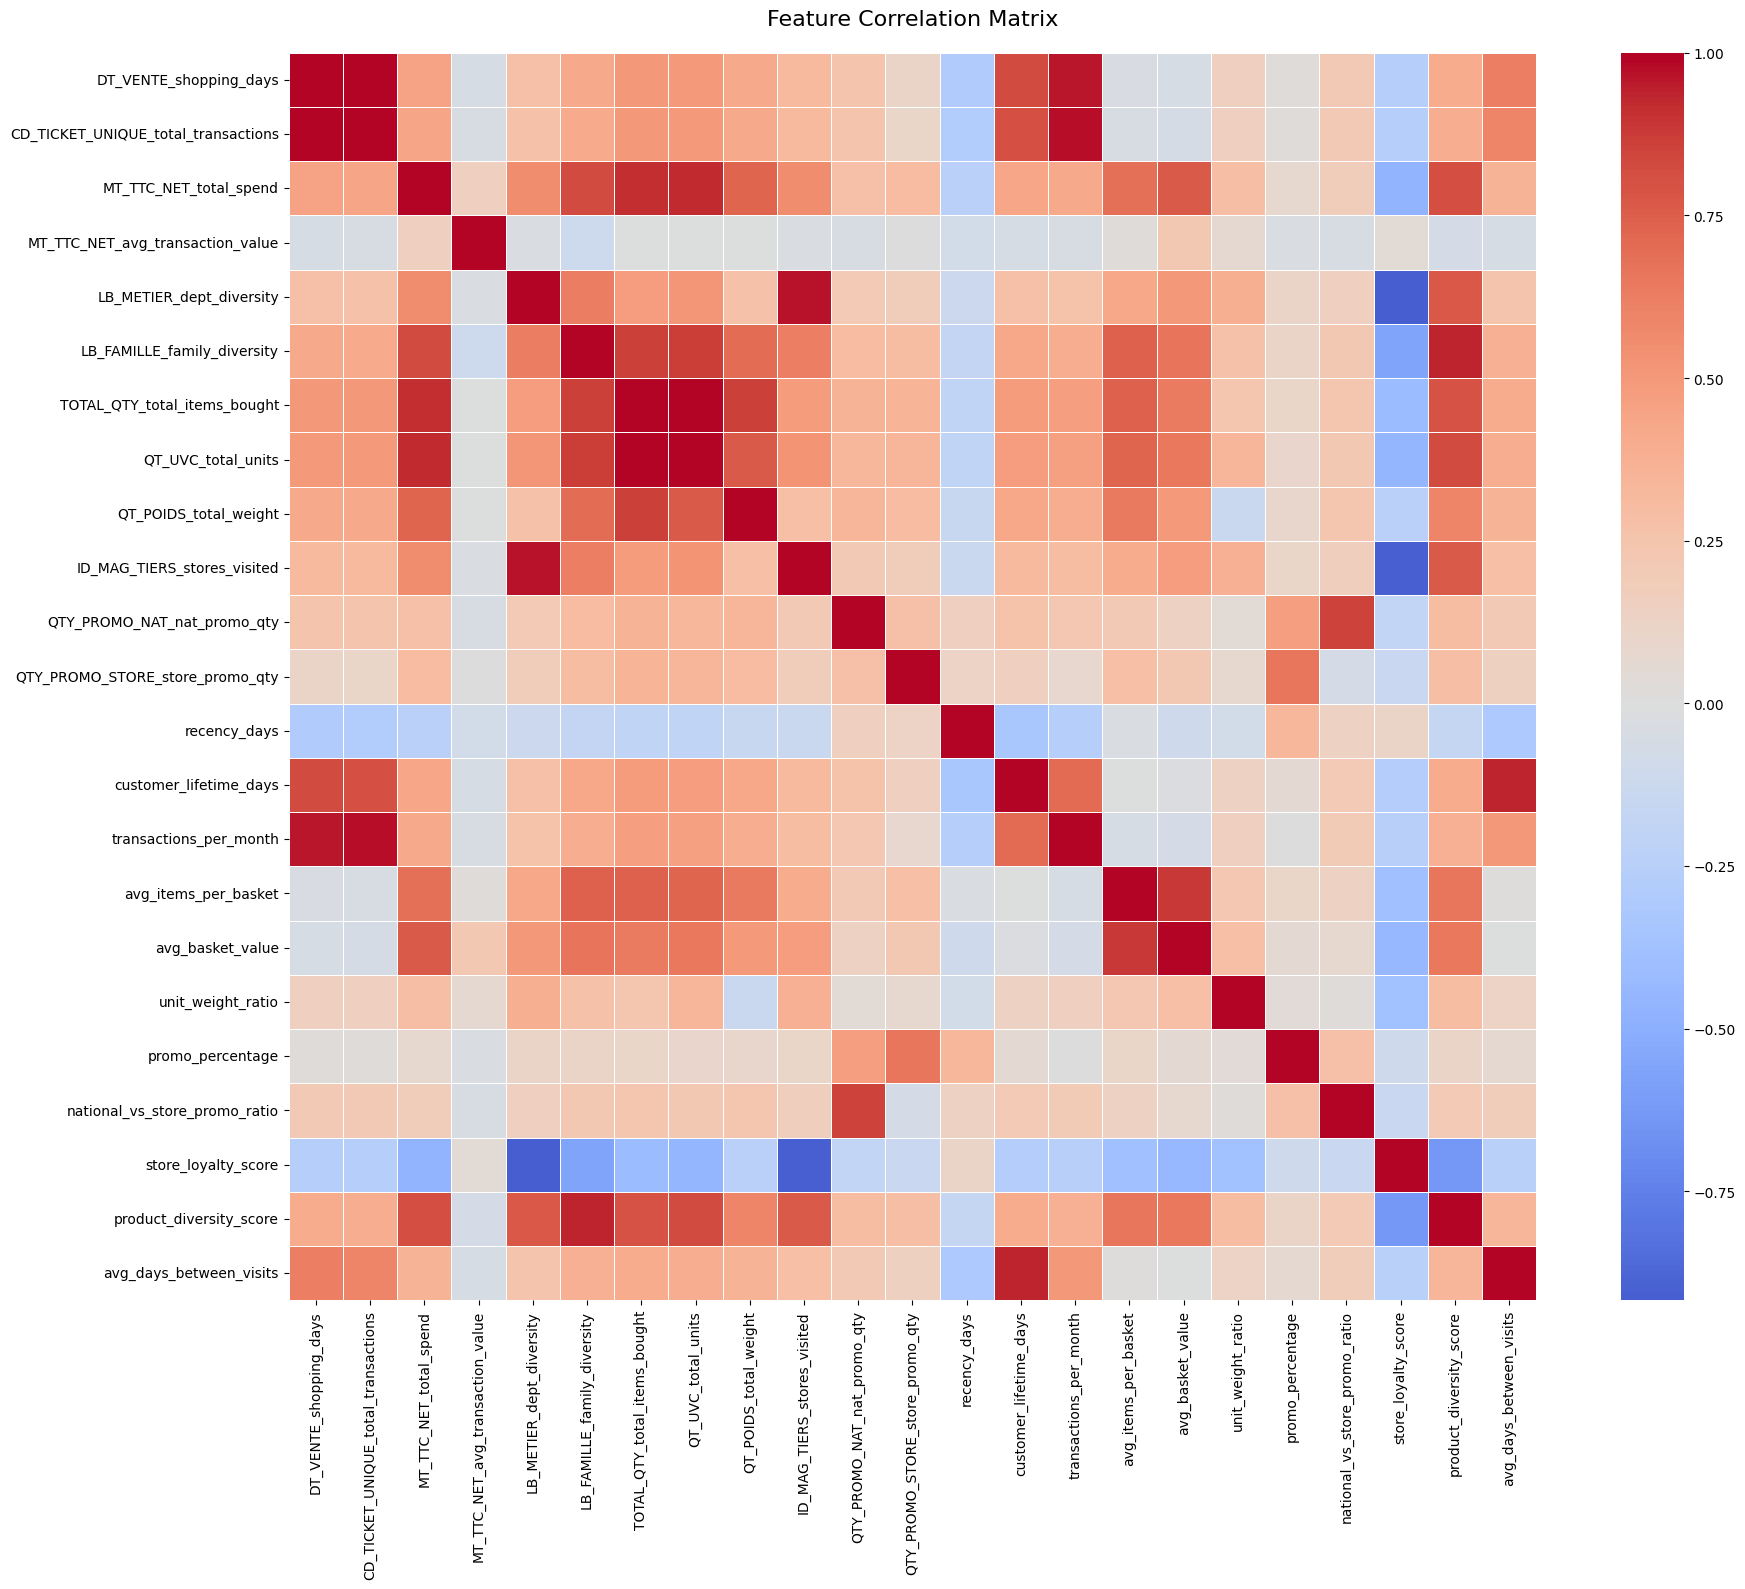

✓ Correlation matrix saved as 'correlation_matrix.png'

Highly correlated feature pairs (|r| > 0.8): 22
  DT_VENTE_shopping_days <-> CD_TICKET_UNIQUE_total_transactions: 0.988
  DT_VENTE_shopping_days <-> customer_lifetime_days: 0.824
  DT_VENTE_shopping_days <-> transactions_per_month: 0.956
  CD_TICKET_UNIQUE_total_transactions <-> customer_lifetime_days: 0.807
  CD_TICKET_UNIQUE_total_transactions <-> transactions_per_month: 0.977
  MT_TTC_NET_total_spend <-> LB_FAMILLE_family_diversity: 0.822
  MT_TTC_NET_total_spend <-> TOTAL_QTY_total_items_bought: 0.914
  MT_TTC_NET_total_spend <-> QT_UVC_total_units: 0.923
  MT_TTC_NET_total_spend <-> product_diversity_score: 0.818
  LB_METIER_dept_diversity <-> ID_MAG_TIERS_stores_visited: 0.969


In [6]:
# ============================================================================
# STEP 3.2: Correlation Analysis
# ============================================================================

print("\n[STEP 3.2] Correlation analysis...")

# Select numeric features only
numeric_features = customer_features.select_dtypes(include=[np.number]).columns.tolist()

# Remove ID columns
numeric_features = [col for col in numeric_features if not col.startswith('NO_TOKEN')]

# Calculate correlation matrix
correlation_matrix = customer_features[numeric_features].corr()

# Plot correlation heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Correlation matrix saved as 'correlation_matrix.png'")
plt.close()

# Identify highly correlated features (|r| > 0.8)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

print(f"\nHighly correlated feature pairs (|r| > 0.8): {len(high_corr_pairs)}")
for feat1, feat2, corr in high_corr_pairs[:10]:
    print(f"  {feat1} <-> {feat2}: {corr:.3f}")


[STEP 3.2] Correlation analysis...


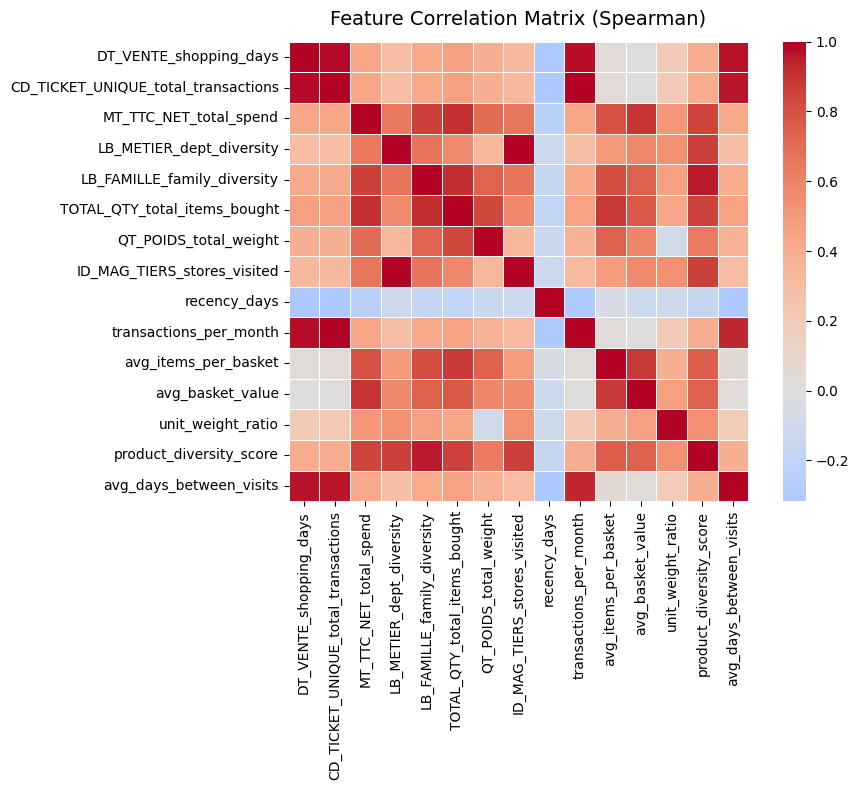

✓ Correlation matrix saved as 'correlation_matrix.png'

Highly correlated feature pairs (|r| > 0.8): 20
  DT_VENTE_shopping_days <-> CD_TICKET_UNIQUE_total_transactions: 0.986
  DT_VENTE_shopping_days <-> transactions_per_month: 0.975
  DT_VENTE_shopping_days <-> avg_days_between_visits: 0.973
  CD_TICKET_UNIQUE_total_transactions <-> transactions_per_month: 0.995
  CD_TICKET_UNIQUE_total_transactions <-> avg_days_between_visits: 0.959
  MT_TTC_NET_total_spend <-> LB_FAMILLE_family_diversity: 0.859
  MT_TTC_NET_total_spend <-> TOTAL_QTY_total_items_bought: 0.910
  MT_TTC_NET_total_spend <-> avg_basket_value: 0.889
  MT_TTC_NET_total_spend <-> product_diversity_score: 0.851
  LB_METIER_dept_diversity <-> ID_MAG_TIERS_stores_visited: 0.990


In [7]:
# ============================================================================
# STEP 3.3: Correlation Analysis simplified
# ============================================================================

print("\n[STEP 3.2] Correlation analysis...")

# Select numeric features only
numeric_features = customer_features.select_dtypes(include=[np.number]).columns.tolist()

# Remove ID columns
numeric_features = [col for col in numeric_features if not col.startswith("NO_TOKEN")]

# Exclude specific variables
exclude_cols = [
    "store_loyalty_score",
    "national_vs_store_promo_ratio",
    "promo_percentage",
    "QTY_PROMO_STORE_store_promo_qty",
    "QTY_PROMO_NAT_nat_promo_qty",
    "ID_LIEU_DE_VENTE_stores_visited",
    "MT_TTC_NET_avg_transaction_value",
    "QT_UVC_total_units",
    "customer_lifetime_days",
]
numeric_features = [c for c in numeric_features if c not in exclude_cols]

# Calculate correlation matrix
correlation_matrix = customer_features[numeric_features].corr(method="spearman")

# Plot correlation heatmap (smaller)
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Feature Correlation Matrix (Spearman)", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Correlation matrix saved as 'correlation_matrix.png'")
plt.close()

# Identify highly correlated features (|r| > 0.8)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

print(f"\nHighly correlated feature pairs (|r| > 0.8): {len(high_corr_pairs)}")
for feat1, feat2, corr in high_corr_pairs[:10]:
    print(f"  {feat1} <-> {feat2}: {corr:.3f}")


[STEP 3.3] RFM Analysis visualization...


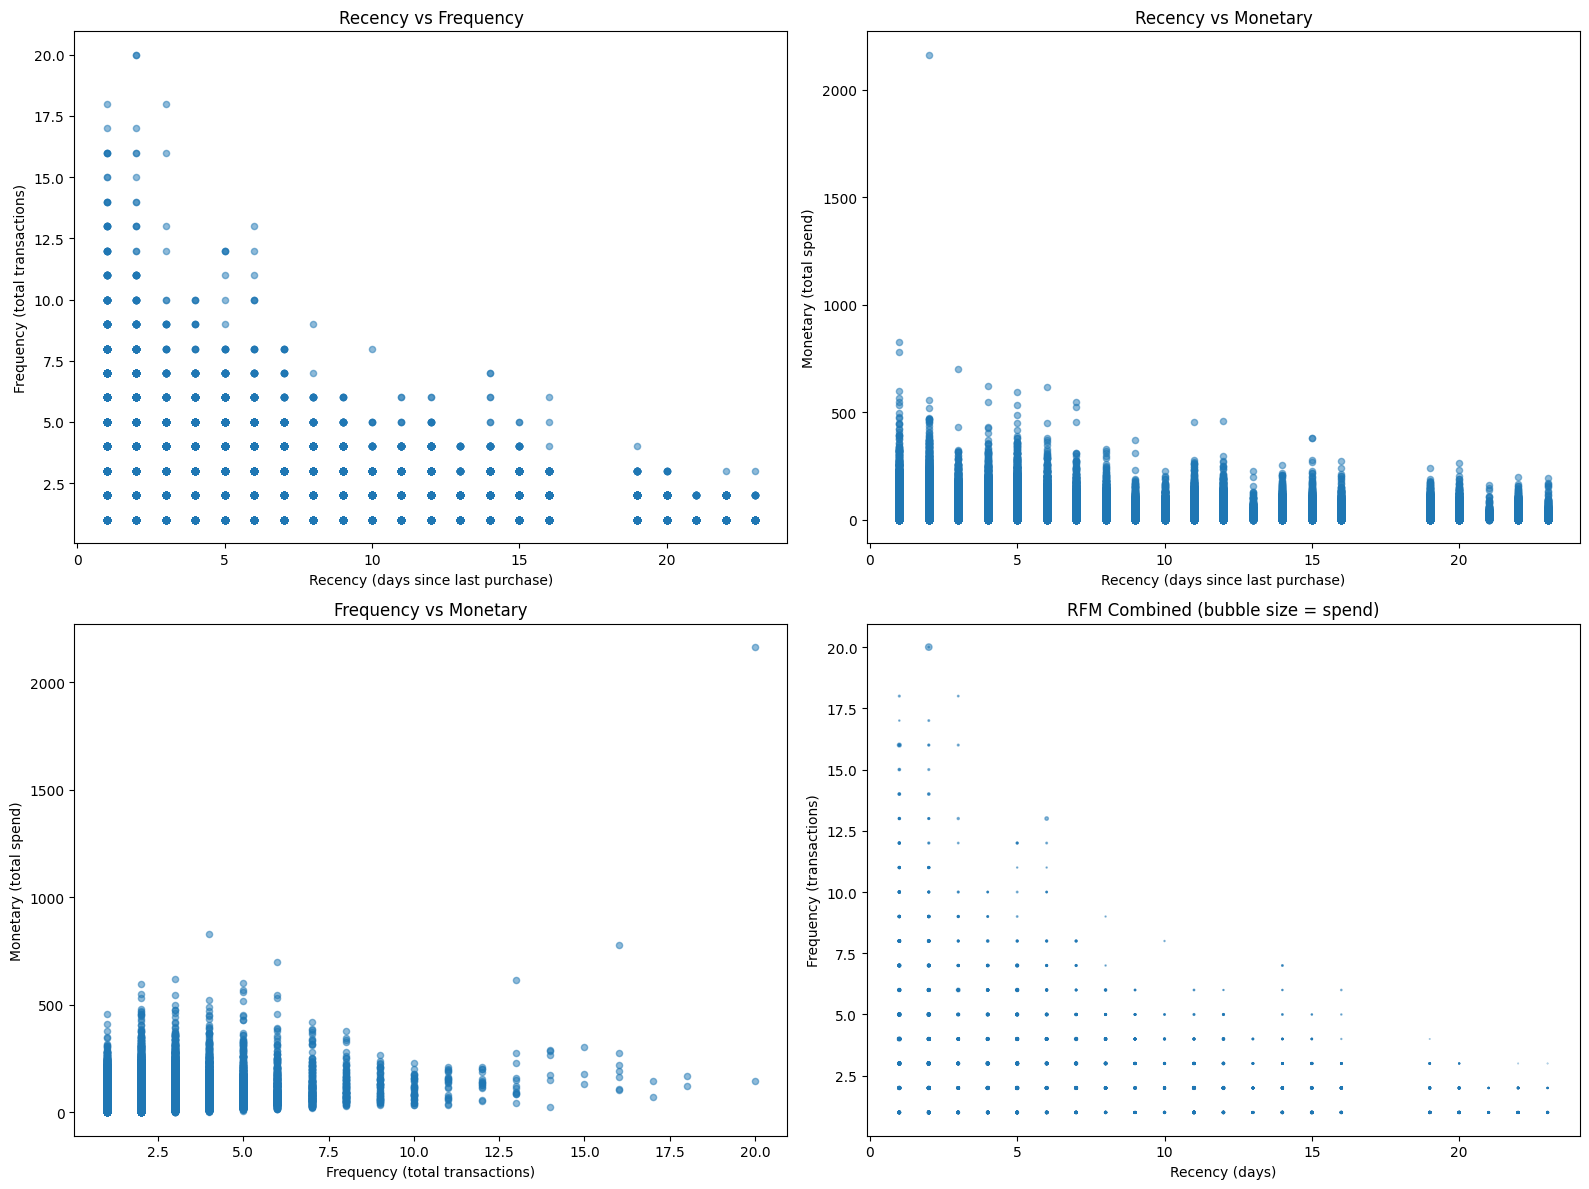

✓ RFM analysis plots saved as 'rfm_analysis.png'


In [8]:
# ============================================================================
# STEP 3.3: RFM Analysis Visualization
# ============================================================================

print("\n[STEP 3.3] RFM Analysis visualization...")

# Create RFM scatter plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Recency vs Frequency
axes[0, 0].scatter(customer_features['recency_days'], 
                   customer_features['CD_TICKET_UNIQUE_total_transactions'],
                   alpha=0.5, s=20)
axes[0, 0].set_xlabel('Recency (days since last purchase)')
axes[0, 0].set_ylabel('Frequency (total transactions)')
axes[0, 0].set_title('Recency vs Frequency')

# Recency vs Monetary
axes[0, 1].scatter(customer_features['recency_days'], 
                   customer_features['MT_TTC_NET_total_spend'],
                   alpha=0.5, s=20)
axes[0, 1].set_xlabel('Recency (days since last purchase)')
axes[0, 1].set_ylabel('Monetary (total spend)')
axes[0, 1].set_title('Recency vs Monetary')

# Frequency vs Monetary
axes[1, 0].scatter(customer_features['CD_TICKET_UNIQUE_total_transactions'],
                   customer_features['MT_TTC_NET_total_spend'],
                   alpha=0.5, s=20)
axes[1, 0].set_xlabel('Frequency (total transactions)')
axes[1, 0].set_ylabel('Monetary (total spend)')
axes[1, 0].set_title('Frequency vs Monetary')

# 3D-like representation using bubble size
axes[1, 1].scatter(customer_features['recency_days'],
                   customer_features['CD_TICKET_UNIQUE_total_transactions'],
                   s=customer_features['MT_TTC_NET_total_spend']/100,
                   alpha=0.5)
axes[1, 1].set_xlabel('Recency (days)')
axes[1, 1].set_ylabel('Frequency (transactions)')
axes[1, 1].set_title('RFM Combined (bubble size = spend)')

plt.tight_layout()
plt.show()
plt.savefig('rfm_analysis.png', dpi=300, bbox_inches='tight')
print("✓ RFM analysis plots saved as 'rfm_analysis.png'")
plt.close()

In [9]:
## Here the RFM analysis shows a very good information first, that there is a real relationship between recency and frequency, the less recency the more frequency
## Another good info is that the less recency the more monetary (more or less) which is good i we could identify a first segment here.
## Frequency monetary graph show that more frequency more monetary
## Bubble chart useless

In [10]:
# ============================================================================
# PART 4: CLUSTERING PREPARATION
# ============================================================================

print("\n" + "=" * 80)
print("PART 4: CLUSTERING PREPARATION")
print("=" * 80)


PART 4: CLUSTERING PREPARATION


In [11]:
# ============================================================================
# STEP 4.1: Feature Selection for Clustering
# ============================================================================

print("\n[STEP 4.1] Selecting features for clustering...")

# Define clustering features (remove highly correlated and redundant features)
clustering_features = [
    # RFM Core
    'recency_days',
    'MT_TTC_NET_total_spend',
    
    # Behavioral
    'avg_basket_value',
    'transactions_per_month',
    
    # Product preferences
    'product_diversity_score',
    
    # Promotional behavior
    'promo_percentage',
    
    # Store behavior
    'store_loyalty_score',

]

# Filter features that exist in dataframe
clustering_features = [f for f in clustering_features if f in customer_features.columns]

print(f"Selected {len(clustering_features)} features for clustering:")
for i, feat in enumerate(clustering_features, 1):
    print(f"  {i}. {feat}")

# Create clustering dataset
df_clustering = customer_features[['NO_TOKEN_CB'] + clustering_features].copy()

# Handle missing values
print(f"\nMissing values before imputation:\n{df_clustering[clustering_features].isnull().sum()}")
df_clustering[clustering_features] = df_clustering[clustering_features].fillna(
    df_clustering[clustering_features].median()
)

# Handle infinite values
df_clustering[clustering_features] = df_clustering[clustering_features].replace(
    [np.inf, -np.inf], np.nan
).fillna(df_clustering[clustering_features].median())

print(f"✓ Clustering dataset prepared: {df_clustering.shape}")



[STEP 4.1] Selecting features for clustering...
Selected 7 features for clustering:
  1. recency_days
  2. MT_TTC_NET_total_spend
  3. avg_basket_value
  4. transactions_per_month
  5. product_diversity_score
  6. promo_percentage
  7. store_loyalty_score

Missing values before imputation:
recency_days               0
MT_TTC_NET_total_spend     0
avg_basket_value           0
transactions_per_month     0
product_diversity_score    0
promo_percentage           0
store_loyalty_score        0
dtype: int64
✓ Clustering dataset prepared: (121112, 8)


In [12]:
# ============================================================================
# STEP 4.2: Feature Scaling
# ============================================================================

print("\n[STEP 4.2] Scaling features...")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering[clustering_features])

print(f"✓ Features scaled using StandardScaler")
print(f"  Shape: {X_scaled.shape}")
print(f"  Mean: {X_scaled.mean():.6f}")
print(f"  Std: {X_scaled.std():.6f}")


[STEP 4.2] Scaling features...
✓ Features scaled using StandardScaler
  Shape: (121112, 7)
  Mean: 0.000000
  Std: 1.000000



[STEP 3.3] Correlation analysis (clustering_features)...


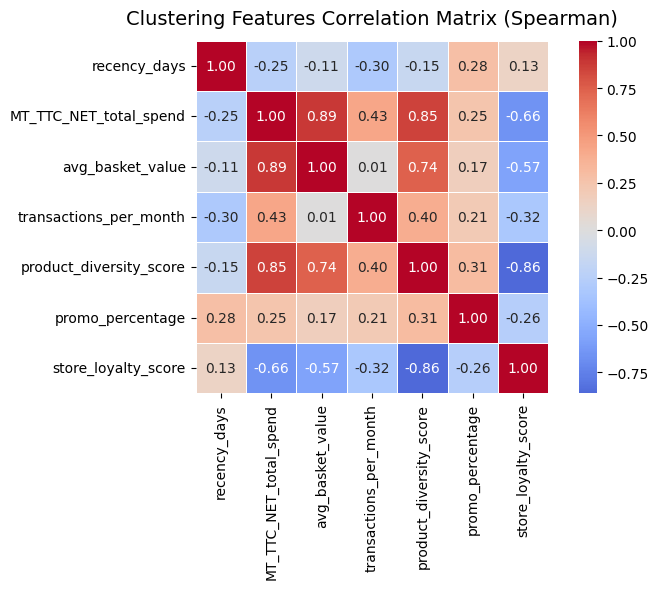

✓ Correlation matrix saved as 'correlation_matrix_clustering_features.png'

Highly correlated feature pairs (|r| > 0.8): 3
  MT_TTC_NET_total_spend <-> avg_basket_value: 0.889
  MT_TTC_NET_total_spend <-> product_diversity_score: 0.851
  product_diversity_score <-> store_loyalty_score: -0.861


In [13]:
# ============================================================================
# STEP 3.3: Correlation Analysis (clustering_features only)
# ============================================================================

print("\n[STEP 3.3] Correlation analysis (clustering_features)...")

clustering_features = [
    # RFM Core
    "recency_days",
    "MT_TTC_NET_total_spend",
    # Behavioral
    "avg_basket_value",
    "transactions_per_month",
    # Product preferences
    "product_diversity_score",
    # Promotional behavior
    "promo_percentage",
    # Store behavior
    "store_loyalty_score",
]

# Keep only columns that exist + are numeric
existing = [c for c in clustering_features if c in customer_features.columns]
missing = [c for c in clustering_features if c not in customer_features.columns]
if missing:
    print(f"⚠ Missing columns (ignored): {missing}")

numeric_existing = customer_features[existing].select_dtypes(include=[np.number]).columns.tolist()
non_numeric = [c for c in existing if c not in numeric_existing]
if non_numeric:
    print(f"⚠ Non-numeric columns (ignored): {non_numeric}")

features = numeric_existing

# Correlation matrix (Spearman)
correlation_matrix = customer_features[features].corr(method="spearman")

# Plot correlation heatmap (smaller)
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,          # small matrix -> readable
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Clustering Features Correlation Matrix (Spearman)", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("correlation_matrix_clustering_features.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Correlation matrix saved as 'correlation_matrix_clustering_features.png'")
plt.close()

# Identify highly correlated features (|r| > 0.8)
high_corr_pairs = []
cols = correlation_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = correlation_matrix.iloc[i, j]
        if abs(r) > 0.8:
            high_corr_pairs.append((cols[i], cols[j], r))

print(f"\nHighly correlated feature pairs (|r| > 0.8): {len(high_corr_pairs)}")
for feat1, feat2, corr in high_corr_pairs:
    print(f"  {feat1} <-> {feat2}: {corr:.3f}")

In [14]:
# ============================================================================
# PART 5: ACP
# ============================================================================

print("\n" + "=" * 80)
print("PART 5: K-MEANS CLUSTERING")
print("=" * 80)


PART 5: K-MEANS CLUSTERING


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Variables à regrouper
X_cols = ["MT_TTC_NET_total_spend", "avg_basket_value", "product_diversity_score"]

# --- X (features) ---
X_df = customer_features[X_cols].copy()
X_df = X_df.select_dtypes(include=[np.number])  # sécurité si une colonne n'est pas numérique
X_df = X_df.dropna()

# --- Standardisation ---
scaler = StandardScaler()
X = scaler.fit_transform(X_df)

# --- y (cible) ---
# IMPORTANT : pour une régression, il faut une cible.
# Ici on prend MT_TTC_NET_total_spend comme exemple (à remplacer si tu as une autre cible).
y = customer_features.loc[X_df.index, "MT_TTC_NET_total_spend"].values

# --- Régression linéaire ---
model = LinearRegression()
model.fit(X, y)

# --- Nouvelle variable ---
customer_features.loc[X_df.index, "combinaison"] = model.predict(X)

In [16]:
# High level of correlation between MT_TTC_NET_total_spend, avg_basket_value, product_diversity_score 
# so we will merge them together to have a better clusterization.

In [17]:
# ============================================================================
# PART 5: K-MEANS CLUSTERING
# ============================================================================

print("\n" + "=" * 80)
print("PART 5: K-MEANS CLUSTERING")
print("=" * 80)



PART 5: K-MEANS CLUSTERING


In [18]:
# here we use only the selected feature and the new one called "combinaison"


[STEP 5.1] Determining optimal number of clusters (profile_metrics)...
Using 9 features: ['recency_days', 'CD_TICKET_UNIQUE_total_transactions', 'MT_TTC_NET_total_spend', 'avg_basket_value', 'transactions_per_month', 'promo_percentage', 'product_diversity_score', 'store_loyalty_score', 'combinaison']
Rows used for clustering: 121,112
Donesting k=2... 
Donesting k=3... 
Donesting k=4... 
Donesting k=5... 
Donesting k=6... 
Donesting k=7... 
Donesting k=8... 
Donesting k=9... 
Donesting k=10... 


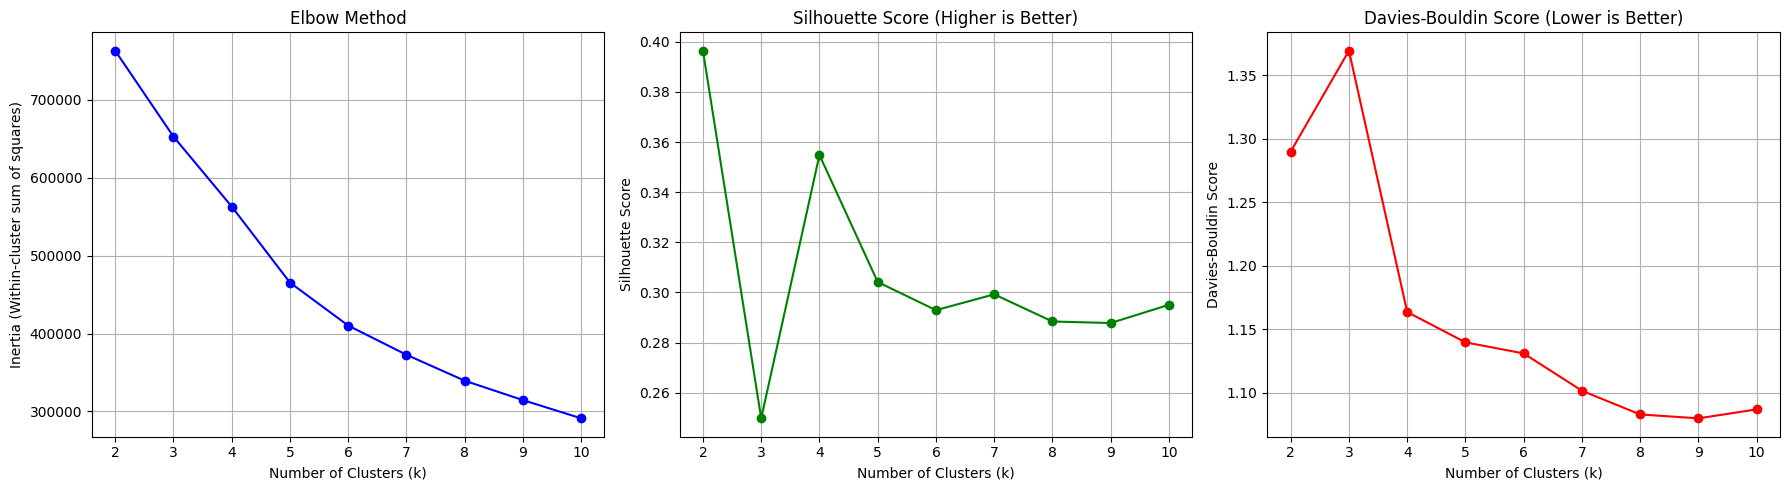


✓ Clustering metrics saved as 'clustering_metrics.png'

Recommended number of clusters:
  Based on Silhouette Score: k=2 (score: 0.396)
  Based on Davies-Bouldin Score: k=9 (score: 1.080)


In [19]:
# ============================================================================
# STEP 5.1: Determine Optimal Number of Clusters (profile_metrics + "combinaison")
# ============================================================================

print("\n[STEP 5.1] Determining optimal number of clusters (profile_metrics)...")

profile_metrics = [
    "recency_days",
    "CD_TICKET_UNIQUE_total_transactions",
    "MT_TTC_NET_total_spend",
    "avg_basket_value",
    "transactions_per_month",
    "promo_percentage",
    "product_diversity_score",
    "store_loyalty_score",
    "combinaison",  # nouvelle variable
]

# --- Build X from selected features only ---
existing = [c for c in profile_metrics if c in customer_features.columns]
missing = [c for c in profile_metrics if c not in customer_features.columns]
if missing:
    print(f"⚠ Missing columns (ignored): {missing}")

X_df = customer_features[existing].select_dtypes(include=[np.number]).copy()
non_numeric = [c for c in existing if c not in X_df.columns]
if non_numeric:
    print(f"⚠ Non-numeric columns (ignored): {non_numeric}")

# drop rows with NA to align all metrics
X_df = X_df.dropna()
used_features = X_df.columns.tolist()
print(f"Using {len(used_features)} features: {used_features}")
print(f"Rows used for clustering: {len(X_df):,}")

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

# --- Evaluate k ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

k_range = range(2, 11)
inertias, silhouette_scores, davies_bouldin_scores = [], [], []

for k in k_range:
    print(f"  Testing k={k}...", end=" ")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    print("Done")

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(list(k_range), inertias, "bo-")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (Within-cluster sum of squares)")
axes[0].set_title("Elbow Method")
axes[0].grid(True)

axes[1].plot(list(k_range), silhouette_scores, "go-")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score (Higher is Better)")
axes[1].grid(True)

axes[2].plot(list(k_range), davies_bouldin_scores, "ro-")
axes[2].set_xlabel("Number of Clusters (k)")
axes[2].set_ylabel("Davies-Bouldin Score")
axes[2].set_title("Davies-Bouldin Score (Lower is Better)")
axes[2].grid(True)

plt.tight_layout()
plt.savefig("clustering_metrics.png", dpi=300, bbox_inches="tight")  # save BEFORE show
plt.show()
print("\n✓ Clustering metrics saved as 'clustering_metrics.png'")
plt.close()

# --- Recommend k ---
optimal_k_silhouette = list(k_range)[int(np.argmax(silhouette_scores))]
optimal_k_db = list(k_range)[int(np.argmin(davies_bouldin_scores))]

print(f"\nRecommended number of clusters:")
print(f"  Based on Silhouette Score: k={optimal_k_silhouette} (score: {max(silhouette_scores):.3f})")
print(f"  Based on Davies-Bouldin Score: k={optimal_k_db} (score: {min(davies_bouldin_scores):.3f})")

In [27]:
# ============================================================================
# STEP 5.2: Final Clustering with Optimal K (profile_metrics + "combinaison")
# ============================================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Choisir k
optimal_k = 5

print(f"\n[STEP 5.2] Performing final clustering with k={optimal_k}...")

# Features utilisées (identiques à la step 5.1)
profile_metrics = [
    "recency_days",
    "CD_TICKET_UNIQUE_total_transactions",
    "MT_TTC_NET_total_spend",
    "avg_basket_value",
    "transactions_per_month",
    "promo_percentage",
    "product_diversity_score",
    "store_loyalty_score",
    "combinaison",
]

# --- Build df_clustering + X_scaled ---
existing = [c for c in profile_metrics if c in customer_features.columns]
missing = [c for c in profile_metrics if c not in customer_features.columns]
if missing:
    print(f"⚠ Missing columns (ignored): {missing}")

df_clustering = customer_features[existing].select_dtypes(include=[np.number]).copy()
non_numeric = [c for c in existing if c not in df_clustering.columns]
if non_numeric:
    print(f"⚠ Non-numeric columns (ignored): {non_numeric}")

df_clustering = df_clustering.dropna()
used_features = df_clustering.columns.tolist()
print(f"Using {len(used_features)} features: {used_features}")
print(f"Rows used for clustering: {len(df_clustering):,}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering)

# --- Fit KMeans ---
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, max_iter=500)
df_clustering["Cluster"] = kmeans_final.fit_predict(X_scaled)

print("✓ Clustering complete")
print(f"  Silhouette Score: {silhouette_score(X_scaled, df_clustering['Cluster']):.3f}")
print(f"  Davies-Bouldin Score: {davies_bouldin_score(X_scaled, df_clustering['Cluster']):.3f}")

# Cluster size distribution
print("\nCluster distribution:")
print(df_clustering["Cluster"].value_counts().sort_index())

print("\nCluster percentages:")
print((df_clustering["Cluster"].value_counts(normalize=True).sort_index() * 100).round(2))


[STEP 5.2] Performing final clustering with k=5...
Using 9 features: ['recency_days', 'CD_TICKET_UNIQUE_total_transactions', 'MT_TTC_NET_total_spend', 'avg_basket_value', 'transactions_per_month', 'promo_percentage', 'product_diversity_score', 'store_loyalty_score', 'combinaison']
Rows used for clustering: 121,112
✓ Clustering complete
  Silhouette Score: 0.304
  Davies-Bouldin Score: 1.140

Cluster distribution:
Cluster
0    58681
1    12326
2     9576
3    33457
4     7072
Name: count, dtype: int64

Cluster percentages:
Cluster
0    48.45
1    10.18
2     7.91
3    27.62
4     5.84
Name: proportion, dtype: float64



[STEP 5.3] Creating PCA visualization...


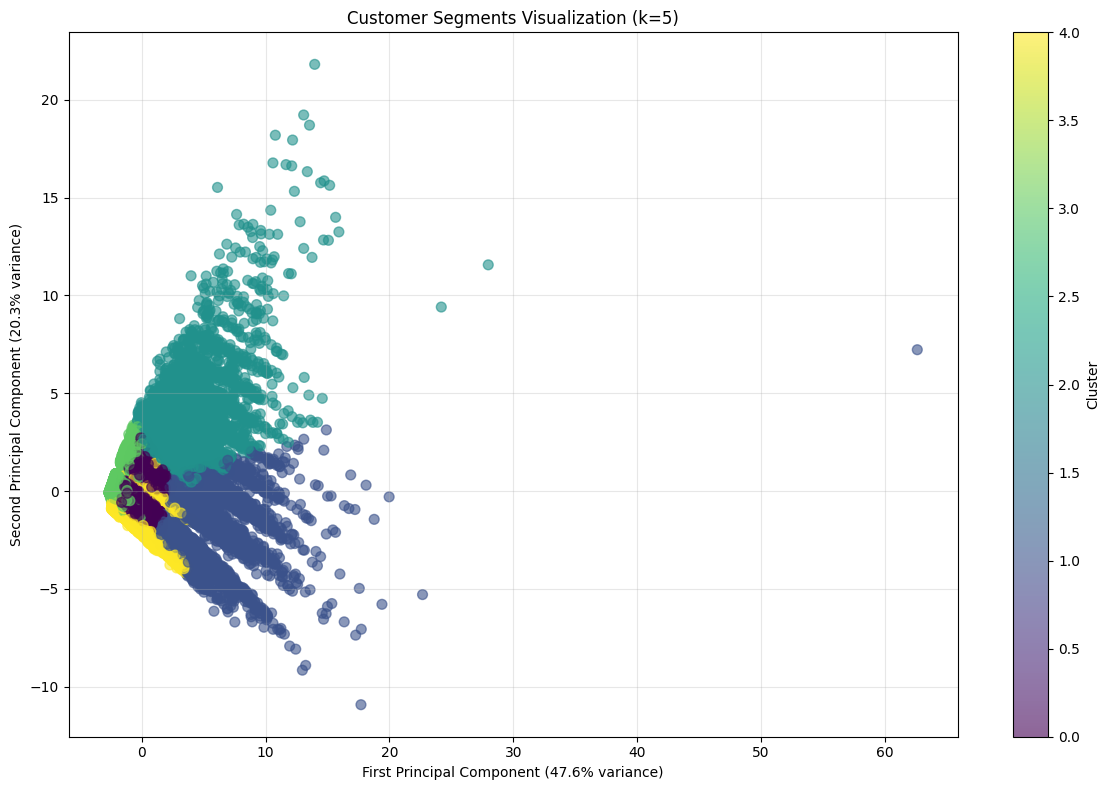

✓ PCA visualization saved as 'cluster_visualization_pca.png'

PCA explained variance (2 components): 67.9%


In [28]:
# ============================================================================
# STEP 5.3: PCA Visualization (profile_metrics + "combinaison")
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("\n[STEP 5.3] Creating PCA visualization...")

# (Optionnel sécurité) vérifier que X_scaled / df_clustering / optimal_k existent déjà
# - X_scaled : matrice standardisée utilisée pour KMeans
# - df_clustering : dataframe contenant les features + colonne "Cluster"
# - optimal_k : nombre de clusters choisi

# Apply PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_clustering["Cluster"],
    cmap="viridis",
    alpha=0.6,
    s=50
)

plt.xlabel(f"First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title(f"Customer Segments Visualization (k={optimal_k})")
plt.colorbar(scatter, label="Cluster")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# save BEFORE show
plt.savefig("cluster_visualization_pca.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ PCA visualization saved as 'cluster_visualization_pca.png'")
plt.close()

print(f"\nPCA explained variance (2 components): {pca.explained_variance_ratio_[:2].sum():.1%}")

In [29]:
# ============================================================================
# PART 6: SEGMENT CHARACTERIZATION (merge clusters back)
# ============================================================================

print("\n" + "=" * 80)
print("PART 6: SEGMENT CHARACTERIZATION")
print("=" * 80)

id_col = "NO_TOKEN_CB"

if id_col not in customer_features.columns:
    raise KeyError(f"'{id_col}' not found in customer_features")

# df_clustering est souvent construit sans l'ID (car non numérique)
if id_col not in df_clustering.columns:
    cluster_map = customer_features.loc[df_clustering.index, [id_col]].copy()
    cluster_map["Cluster"] = df_clustering["Cluster"].values
else:
    cluster_map = df_clustering[[id_col, "Cluster"]].copy()

customer_segments = customer_features.merge(
    cluster_map,
    on=id_col,
    how="left"
)

print("✓ Merge done")
print("  Rows:", len(customer_segments))
print("  Unassigned clusters:", int(customer_segments["Cluster"].isna().sum()))


PART 6: SEGMENT CHARACTERIZATION
✓ Merge done
  Rows: 121112
  Unassigned clusters: 0


In [30]:
# ============================================================================
# STEP 6.1: Statistical Segment Profiles (mean + count + %)
# ============================================================================

print("\n[STEP 6.1] Creating segment profiles...")

profile_metrics = [
    "recency_days",
    "CD_TICKET_UNIQUE_total_transactions",
    "MT_TTC_NET_total_spend",
    "avg_basket_value",
    "transactions_per_month",
    "promo_percentage",
    "product_diversity_score",
    "store_loyalty_score",
    "combinaison",  # inclure la variable créée
]

# Garder uniquement les métriques présentes
profile_metrics = [m for m in profile_metrics if m in customer_segments.columns]

# Assurer que Cluster existe
if "Cluster" not in customer_segments.columns:
    raise KeyError("'Cluster' not found in customer_segments")

# Segment profiles (mean)
segment_profiles = customer_segments.groupby("Cluster")[profile_metrics].mean()

# Ajouter volume et pourcentage
cluster_counts = customer_segments["Cluster"].value_counts().sort_index()
cluster_pct = (customer_segments["Cluster"].value_counts(normalize=True).sort_index() * 100).round(2)

segment_profiles = segment_profiles.join(cluster_counts.rename("n")).join(cluster_pct.rename("pct"))

print("\nSegment Profiles (Mean values):")
print("=" * 100)
print(segment_profiles.round(2))

# Save to CSV
segment_profiles.to_csv("segment_profiles.csv")
print("\n✓ Segment profiles saved to 'segment_profiles.csv'")


[STEP 6.1] Creating segment profiles...

Segment Profiles (Mean values):
         recency_days  CD_TICKET_UNIQUE_total_transactions  \
Cluster                                                      
0                8.65                                 1.22   
1                6.05                                 1.60   
2                4.12                                 3.86   
3                9.33                                 1.11   
4               16.69                                 1.17   

         MT_TTC_NET_total_spend  avg_basket_value  transactions_per_month  \
Cluster                                                                     
0                         30.73             26.47                    1.13   
1                        121.43             83.77                    1.33   
2                         75.08             20.12                    2.65   
3                         14.24             12.98                    1.06   
4                         34.


[STEP 6.2] Characterizing segments...


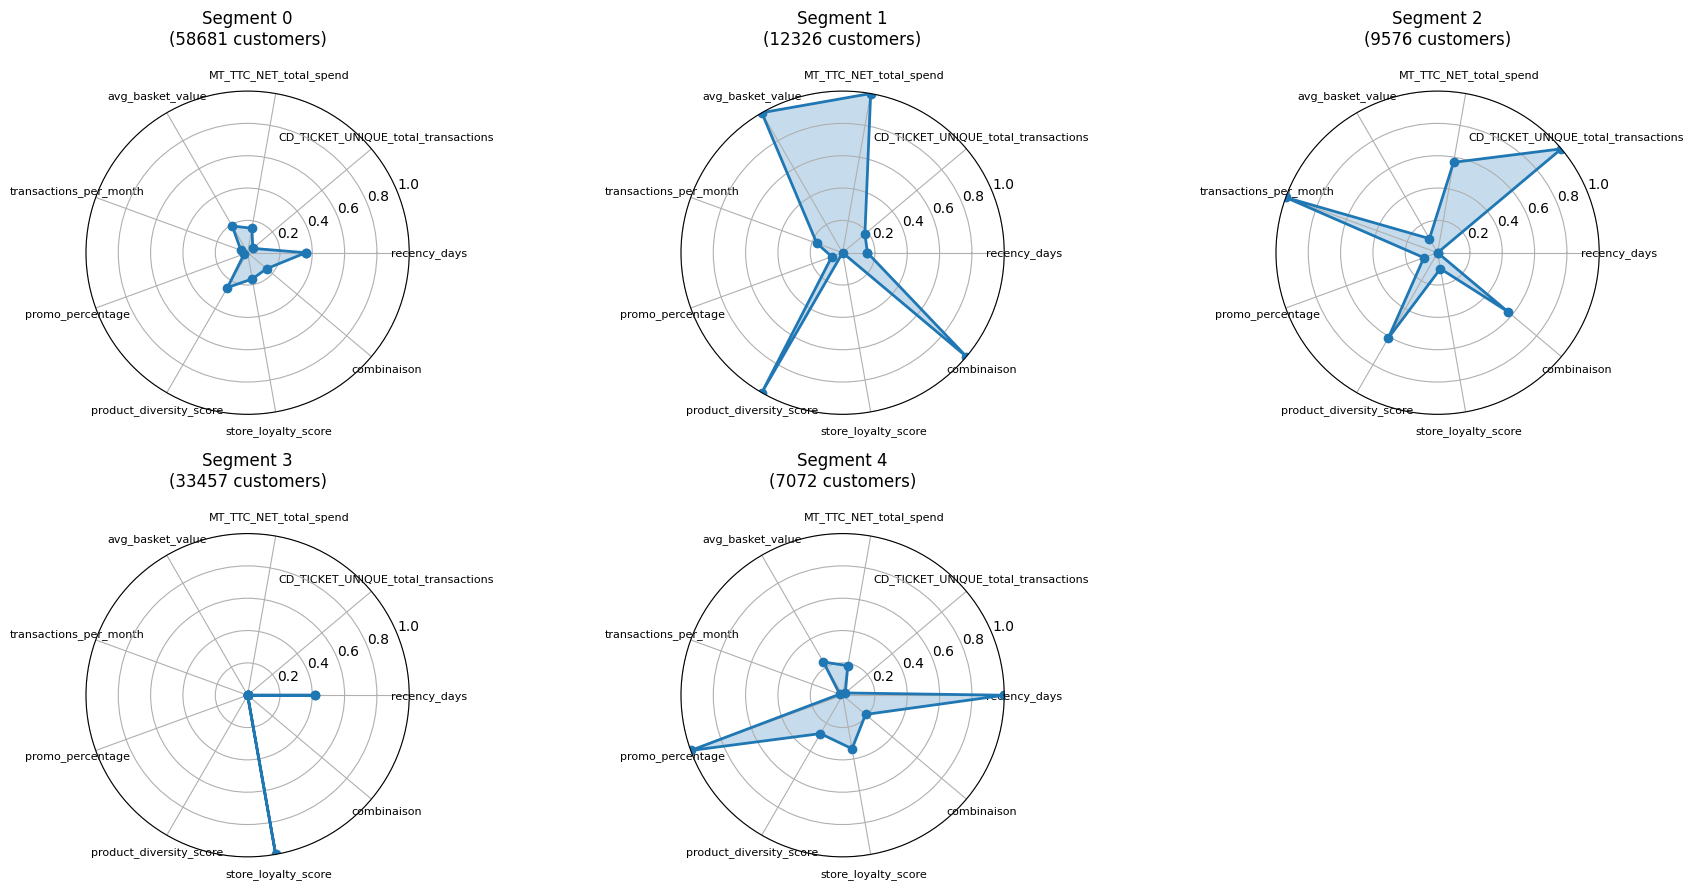

✓ Segment radar charts saved as 'segment_radar_charts.png'


In [31]:
# ============================================================================
# STEP 6.2: Segment Naming and Characterization (Radar charts)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

print("\n[STEP 6.2] Characterizing segments...")

# Metrics à afficher (recalcul proprement depuis segment_profiles)
# -> on exclut n/pct si tu les as ajoutés dans step 6.1
plot_metrics = [c for c in segment_profiles.columns if c not in ["n", "pct"]]

# Angles radar
angles = np.linspace(0, 2 * np.pi, len(plot_metrics), endpoint=False).tolist()
angles += angles[:1]

# Grille de subplots adaptée à optimal_k
n_clusters = int(optimal_k)
n_cols = 3
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6 * n_cols, 4.5 * n_rows),
    subplot_kw=dict(projection="polar")
)

# axes peut être 2D si n_rows>1, sinon 1D
axes = np.array(axes).reshape(-1)

# Normalisation min-max par métrique (sur tous les clusters)
mins = segment_profiles[plot_metrics].min(axis=0)
maxs = segment_profiles[plot_metrics].max(axis=0)
den = (maxs - mins).replace(0, np.nan)  # éviter division par 0

for idx, cluster_id in enumerate(sorted(segment_profiles.index.tolist())):
    if idx >= len(axes):
        break
    ax = axes[idx]

    # Valeurs du cluster (seulement les métriques)
    values = segment_profiles.loc[cluster_id, plot_metrics]
    values_norm = ((values - mins) / den).fillna(0.0).values.tolist()
    values_norm += values_norm[:1]

    ax.plot(angles, values_norm, "o-", linewidth=2)
    ax.fill(angles, values_norm, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(plot_metrics, size=8)
    ax.set_ylim(0, 1)

    n_customers = int(customer_segments["Cluster"].eq(cluster_id).sum())
    ax.set_title(f"Segment {cluster_id}\n({n_customers} customers)", size=12, pad=18)
    ax.grid(True)

# Supprimer les axes inutilisés
for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("segment_radar_charts.png", dpi=300, bbox_inches="tight")  # save BEFORE show
plt.show()
print("✓ Segment radar charts saved as 'segment_radar_charts.png'")
plt.close()

In [25]:
# ============================================================================
# STEP 6.3: Business Insights Summary (adapted)
# ============================================================================

print("\n[STEP 6.3] Generating business insights...")

# Colonnes à agréger (on garde uniquement celles qui existent)
id_col = "NO_TOKEN_CB"
agg_spec = {}

if id_col in customer_segments.columns:
    agg_spec[id_col] = "count"

if "MT_TTC_NET_total_spend" in customer_segments.columns:
    agg_spec["MT_TTC_NET_total_spend"] = ["sum", "mean"]

if "CD_TICKET_UNIQUE_total_transactions" in customer_segments.columns:
    agg_spec["CD_TICKET_UNIQUE_total_transactions"] = "mean"

if "recency_days" in customer_segments.columns:
    agg_spec["recency_days"] = "mean"

if "promo_percentage" in customer_segments.columns:
    agg_spec["promo_percentage"] = "mean"

if "store_loyalty_score" in customer_segments.columns:
    agg_spec["store_loyalty_score"] = "mean"

if "combinaison" in customer_segments.columns:
    agg_spec["combinaison"] = "mean"

if "Cluster" not in customer_segments.columns:
    raise KeyError("'Cluster' not found in customer_segments")

segment_summary = customer_segments.groupby("Cluster").agg(agg_spec).round(2)

# Aplatir les colonnes multi-index (sum/mean)
segment_summary.columns = [
    "_".join([str(x) for x in col if x]).strip("_") if isinstance(col, tuple) else col
    for col in segment_summary.columns
]

# Renommer proprement si présent
rename_map = {
    id_col: "Customer_Count",
    "MT_TTC_NET_total_spend_sum": "Total_Revenue",
    "MT_TTC_NET_total_spend_mean": "Avg_Revenue_Per_Customer",
    "CD_TICKET_UNIQUE_total_transactions": "Avg_Transactions",
    "recency_days": "Avg_Recency",
    "promo_percentage": "Avg_Promo_%",
    "store_loyalty_score": "Avg_Store_Loyalty",
    "combinaison": "Avg_Combinaison",
}
segment_summary = segment_summary.rename(columns={k: v for k, v in rename_map.items() if k in segment_summary.columns})

# Revenue contribution (%)
if "Total_Revenue" in segment_summary.columns:
    segment_summary["Revenue_%"] = (
        segment_summary["Total_Revenue"] / segment_summary["Total_Revenue"].sum() * 100
    ).round(2)

print("\nSegment Business Summary:")
print("=" * 120)
print(segment_summary)

# Save results
segment_summary.to_csv("segment_business_summary.csv")

# Sauvegarde clients + segments
customer_segments.to_csv("customers_with_segments.csv", index=False)

print("\n✓ Business summary saved to 'segment_business_summary.csv'")
print("✓ Customer segments saved to 'customers_with_segments.csv'")


[STEP 6.3] Generating business insights...

Segment Business Summary:
         NO_TOKEN_CB_count  Total_Revenue  Avg_Revenue_Per_Customer  \
Cluster                                                               
0                    35098      499471.32                     14.23   
1                    62814     1923125.62                     30.62   
2                    13445     1580504.88                    117.55   
3                     9755      733510.83                     75.19   

         CD_TICKET_UNIQUE_total_transactions_mean  recency_days_mean  \
Cluster                                                                
0                                            1.11               9.66   
1                                            1.22               9.29   
2                                            1.57               6.60   
3                                            3.85               4.10   

         promo_percentage_mean  store_loyalty_score_mean  combinaison

In [26]:
print("\n" + "=" * 80)
print("CLUSTERING ANALYSIS COMPLETE!")
print("=" * 80)
print(f"\nSegments created: {optimal_k}")
print(f"Total customers segmented: {len(customer_segments)}")
print("\nKey outputs generated:")
print("  1. feature_distributions.png")
print("  2. correlation_matrix.png")
print("  3. rfm_analysis.png")
print("  4. clustering_metrics.png")
print("  5. cluster_visualization_pca.png")
print("  6. segment_radar_charts.png")
print("  7. segment_profiles.csv")
print("  8. segment_business_summary.csv")
print("  9. customers_with_segments.csv")
print("\nProceeding to association rules and recommendations!")



CLUSTERING ANALYSIS COMPLETE!

Segments created: 4
Total customers segmented: 121112

Key outputs generated:
  1. feature_distributions.png
  2. correlation_matrix.png
  3. rfm_analysis.png
  4. clustering_metrics.png
  5. cluster_visualization_pca.png
  6. segment_radar_charts.png
  7. segment_profiles.csv
  8. segment_business_summary.csv
  9. customers_with_segments.csv

Proceeding to association rules and recommendations!


In [33]:
#Testing with Gaussian Mixture Models
from sklearn.mixture import GaussianMixture


In [34]:
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X_scaled)

,"n_components n_components: int, default=1The number of mixture components.",4
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [35]:
customer_segments = gmm.predict(X_scaled)